# Extracting precipitation data from CHIRPS

In [1]:
import pandas as pd
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt


In [2]:
lonlat = pd.read_csv('../data/raw/locations_centroids.csv')

In [3]:
files = sorted(Path("../data/raw/chirps").glob("chirps_pcp_*.nc"))

chirps = xr.open_mfdataset(
    files,
    engine="netcdf4",
    combine="by_coords",
    parallel=False
)

In [4]:
points = lonlat.reset_index(drop=True)

lons = xr.DataArray(
    points.lon.values,
    dims="points"
)

lats = xr.DataArray(
    points.lat.values,
    dims="points"
)

In [5]:
precip = chirps["precip"].sel(
    longitude=lons,
    latitude=lats,
    method="nearest"
)

In [6]:
precip.to_dataframe().isnull().sum()

latitude        0
longitude       0
precip       2192
dtype: int64

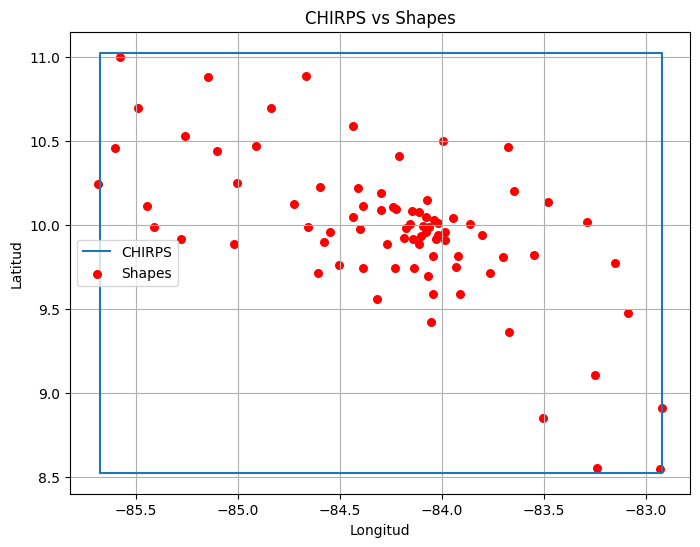

In [7]:
import matplotlib.pyplot as plt

lon_min = float(precip.longitude.min())
lon_max = float(precip.longitude.max())
lat_min = float(precip.latitude.min())
lat_max = float(precip.latitude.max())

plt.figure(figsize=(8, 6))

# Draw CHIRTS domain as a rectangle
plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    label="CHIRPS",
)

# Plot your points
plt.scatter(points.lon, points.lat, c="red", s=30, label="Shapes")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.title("CHIRPS vs Shapes")
plt.grid(True)
plt.show()


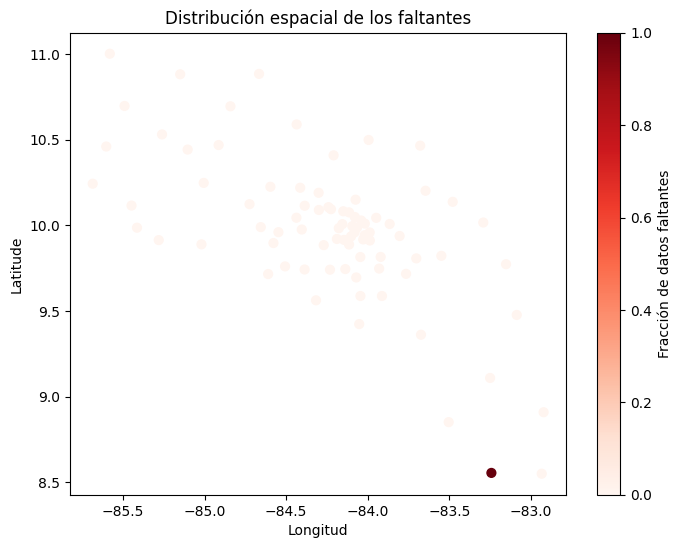

In [8]:
nan_fraction = precip.isnull().mean("time")

plt.figure(figsize=(8, 6))
plt.scatter(points.lon, points.lat, c=nan_fraction, cmap="Reds", s=40)
plt.colorbar(label="Fracción de datos faltantes")
plt.xlabel("Longitud")
plt.ylabel("Latitude")
plt.title("Distribución espacial de los faltantes")
plt.show()

In [9]:
precip_csv = (
    precip
    .to_dataframe()
    .reset_index()
    .assign(
        lon=lambda df: points.loc[df["points"], "lon"].values,
        lat=lambda df: points.loc[df["points"], "lat"].values,
        canton=lambda df: points.loc[df["points"], "canton"].values
    )
    .drop(columns="points")
)

In [10]:
precip_csv

,time,latitude,longitude,precip,lon,lat,canton
0,2020-01-01,10.074997,-84.225006,0.0,-84.225669,10.094073,Alajuela
1,2020-01-01,9.974998,-84.425003,0.0,-84.404370,9.975320,Atenas
2,2020-01-01,10.074997,-84.275002,0.0,-84.299504,10.089460,Grecia
3,2020-01-01,10.674999,-84.825005,0.0,-84.841434,10.694885,Guatuso
4,2020-01-01,10.874996,-84.675003,0.0,-84.666104,10.884147,Los Chiles
...,...,...,...,...,...,...,...
179739,2025-12-31,9.924999,-84.175003,0.0,-84.188947,9.920169,Santa Ana
179740,2025-12-31,9.574997,-84.025002,0.0,-84.044958,9.587117,Tarrazú
179741,2025-12-31,9.974998,-84.075005,0.0,-84.081013,9.958730,Tibás
179742,2025-12-31,9.774998,-84.525002,0.0,-84.506700,9.760047,Turrubares


In [11]:
precip_csv.to_csv('../data/raw/chirps/chirps_precip.csv', index=False)